# Investigating a Deployed ML Model via API

- Author: Sydney Sailors
- Date: 2026-08
- API: ML Penguin Predictor
- Endpoint: https://ml-penguin-predictor.onrender.com/predict
- Target: species

Run all cells top to bottom (**Run All**) before pushing to GitHub.

## M7. Investigating a Deployed Model

This notebook calls a live prediction API and hits it systematically.
The model is already trained and served. 

Your job is to understand its behavior by varying inputs and observing what changes. 

**Your judgment** is what you conclude about where the model is confident, 
where it is fragile, and why.

No model training is required. The API is already live.

## A. Prepare the Project Environment (.venv/)

- Open **only one project in VS Code at a time**.
- Prepare the .venv/: specify Python version and install / upgrade dependencies listed in `pyproject.toml`.
- Open an integrated terminal (PowerShell if Windows) in the **root project** folder and run:

```shell
uv self update
uv python pin 3.14
uv lock --upgrade
uv sync --extra dev --extra docs --upgrade
```


## B. Select the Notebook Kernel

- Click on the **Select Kernel** name in the top-right corner of the notebook interface.
- Choose Python Environments... /
- Choose the recommended local .venv/ from the drop-down menu.
- This will create a new kernel for the notebook and allow the notebook to use packages installed in the .venv/ environment.

## C. Working in Notebooks (Custom Notes)

- To run a cell, press **Ctrl+Enter** (or **Cmd+Enter** on Mac) when done editing the cell.
- Change the type of a cell (e.g., code or markdown) by looking in the lower left corner of the notebook interface.
- Rearrange cells by dragging and dropping them within the notebook.

See [Run Jupyter Notebooks](https://denisecase.github.io/pro-analytics-02/workflow-b-apply-example-project/run-notebook/) for:

- how to **copy a notebook**
- how to release a `project.log` file
- how to deal with a **stuck kernel**
- etc.


## M7. Probing a Model from the Outside

Once a model is deployed, you cannot always see inside it.
But you can learn a great deal by asking it questions systematically:

- **Vary one feature at a time** and watch predictions change.
  This reveals which inputs the model is most sensitive to.
- **Test edge cases** - try values outside the training range, missing fields,
  extreme numbers and observe how the API responds.
- **Build a prediction grid** over two features at once and visualize
  the decision boundary as a heatmap.

Naming what you observe and what it implies about the model is the
judgment this module adds. 
The API call is just a function.

## Section 1. Project Setup and Imports

In [1]:
# === Section 1a. DECLARE IMPORTS ===

from importlib.metadata import version  # to verify
import logging  # for type hinting
import platform  # to verify
from typing import Any  # for type hinting

from datafun_toolkit.logger import get_logger, log_header
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
import seaborn as sns

# === Section 1b. CONFIGURE LOGGER ONCE PER NOTEBOOK ===

LOG: logging.Logger = get_logger("M07", level="DEBUG")
log_header(LOG, "M07")

# === Section 1c. USE THE LOGGER TO VERIFY IMPORTS ===

LOG.info("Confirming installation:")
LOG.info(f"  python:       {platform.python_version()}")
LOG.info(f"  pandas:       {version('pandas')}")
LOG.info(f"  numpy:        {version('numpy')}")
LOG.info(f"  matplotlib:   {version('matplotlib')}")
LOG.info(f"  seaborn:      {version('seaborn')}")
LOG.info(f"  requests:     {version('requests')}")

# === Section 1d. SET PANDAS DISPLAY CONFIGURATION (helps in notebooks) ===

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)

# === Section 1e. GLOBAL CONSTANTS ===

# CUSTOM: update this URL if you deploy your own model.
API_URL: str = "https://ml-penguin-predictor.onrender.com/predict"
LOG.info(f"API endpoint: {API_URL}")

2026-08-13 15:57:06 | INFO | M07 | === RUN START ===
2026-08-13 15:57:06 | INFO | M07 | project=M07
2026-08-13 15:57:06 | INFO | M07 | repo_dir=ml-07-applied
2026-08-13 15:57:06 | INFO | M07 | python=3.14.5
2026-08-13 15:57:06 | INFO | M07 | os=Darwin 20.6.0
2026-08-13 15:57:06 | INFO | M07 | shell=zsh
2026-08-13 15:57:06 | INFO | M07 | cwd=notebooks
2026-08-13 15:57:06 | INFO | M07 | github_actions=False
2026-08-13 15:57:06 | INFO | M07 | Confirming installation:
2026-08-13 15:57:06 | INFO | M07 |   python:       3.14.5
2026-08-13 15:57:06 | INFO | M07 |   pandas:       3.0.5
2026-08-13 15:57:06 | INFO | M07 |   numpy:        2.5.2
2026-08-13 15:57:06 | INFO | M07 |   matplotlib:   3.11.1
2026-08-13 15:57:06 | INFO | M07 |   seaborn:      0.13.2
2026-08-13 15:57:06 | INFO | M07 |   requests:     2.34.2
2026-08-13 15:57:06 | INFO | M07 | API endpoint: https://ml-penguin-predictor.onrender.com/predict


## Section 2. Baseline Predictions

```text
ANALYST CHOICE
Before investigating, confirm the API returns expected results for
known inputs. If these baseline calls fail, the investigation cannot proceed.
```

In [2]:
# === Section 2. Baseline Predictions ===


def predict(payload: dict[str, Any]) -> str:
    """Send a payload to the prediction API and return the predicted species.

    WHY: A single reusable function keeps all API calls consistent.
    Any change to the endpoint or headers only needs to happen here.

    Args:
        payload: dict of feature name -> value.

    Returns:
        Predicted species string, or an error message string.
    """
    try:
        response = requests.post(API_URL, json=payload, timeout=30)
        response.raise_for_status()
        return str(response.json().get("prediction", "NO_PREDICTION_KEY"))
    except requests.exceptions.Timeout:
        return "TIMEOUT (server may be sleeping - try again)"
    except requests.exceptions.RequestException as exc:
        return f"ERROR: {exc}"


# One known example per species from the penguins dataset.
BASELINES: list[dict[str, Any]] = [
    {
        "bill_length_mm": 39.1,
        "bill_depth_mm": 18.7,
        "flipper_length_mm": 181,
        "body_mass_g": 3750,
    },
    {
        "bill_length_mm": 46.5,
        "bill_depth_mm": 17.9,
        "flipper_length_mm": 192,
        "body_mass_g": 3500,
    },
    {
        "bill_length_mm": 46.1,
        "bill_depth_mm": 13.2,
        "flipper_length_mm": 211,
        "body_mass_g": 4500,
    },
]
EXPECTED: list[str] = ["Adelie", "Chinstrap", "Gentoo"]

LOG.info("Baseline predictions:")
for payload, expected in zip(BASELINES, EXPECTED, strict=True):
    result = predict(payload)
    match = "OK" if result == expected else "MISMATCH"
    LOG.info(f"  expected={expected:<10} got={result:<10} [{match}]")

2026-08-13 15:57:06 | INFO | M07 | Baseline predictions:
2026-08-13 15:57:06 | INFO | M07 |   expected=Adelie     got=Adelie     [OK]
2026-08-13 15:57:06 | INFO | M07 |   expected=Chinstrap  got=Chinstrap  [OK]
2026-08-13 15:57:07 | INFO | M07 |   expected=Gentoo     got=Gentoo     [OK]


## Section 3. Feature Sensitivity

```text
ANALYST CHOICE
Vary one feature at a time while holding others fixed.
Observe where the prediction changes. That boundary is the model's
decision for that feature. Decide which features matter most.
```

2026-08-13 15:57:11 | INFO | M07 | bill_length_mm sweep:
2026-08-13 15:57:11 | INFO | M07 |  bill_length_mm prediction
      35.000000     Adelie
      35.517241     Adelie
      36.034483     Adelie
      36.551724     Adelie
      37.068966     Adelie
      37.586207     Adelie
      38.103448     Adelie
      38.620690     Adelie
      39.137931     Adelie
      39.655172     Adelie
      40.172414     Adelie
      40.689655     Adelie
      41.206897     Adelie
      41.724138     Adelie
      42.241379     Adelie
      42.758621  Chinstrap
      43.275862  Chinstrap
      43.793103  Chinstrap
      44.310345  Chinstrap
      44.827586  Chinstrap
      45.344828  Chinstrap
      45.862069  Chinstrap
      46.379310  Chinstrap
      46.896552  Chinstrap
      47.413793  Chinstrap
      47.931034  Chinstrap
      48.448276  Chinstrap
      48.965517  Chinstrap
      49.482759  Chinstrap
      50.000000  Chinstrap


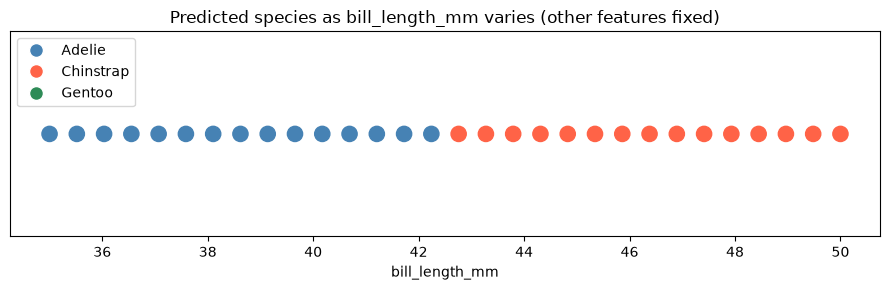

2026-08-13 15:57:11 | INFO | M07 | ANALYST CHOICE: Where does the prediction shift and does that match your expectation?


In [3]:
# === Section 3. Feature Sensitivity ===


def sweep_feature(
    base: dict[str, Any],
    feature: str,
    values: list[float],
) -> pd.DataFrame:
    """Vary one feature across a range and collect predictions.

    WHY: Holding all other features fixed isolates the effect of one input.
    This is the simplest way to probe a black-box model.

    Args:
        base: baseline payload with all four features set.
        feature: the feature name to vary.
        values: list of values to try for that feature.

    Returns:
        DataFrame with columns [feature, 'prediction'].
    """
    rows = []
    for v in values:
        payload = {**base, feature: v}
        rows.append({feature: v, "prediction": predict(payload)})
    return pd.DataFrame(rows)


# Use the Adelie baseline and sweep bill_length_mm. Change feature sweep from 20 to 30.
BASE: dict[str, Any] = BASELINES[0]
bill_lengths = list(np.linspace(35, 50, 30))
df_sweep = sweep_feature(BASE, "bill_length_mm", bill_lengths)

LOG.info("bill_length_mm sweep:")
LOG.info(df_sweep.to_string(index=False))

# Plot prediction vs feature value.
species_order = ["Adelie", "Chinstrap", "Gentoo"]
color_map = {"Adelie": "steelblue", "Chinstrap": "tomato", "Gentoo": "seagreen"}
colors = df_sweep["prediction"].map(color_map).fillna("gray")

plt.figure(figsize=(9, 3))
plt.scatter(df_sweep["bill_length_mm"], [1] * len(df_sweep), c=colors, s=120)
plt.xlabel("bill_length_mm")
plt.yticks([])
plt.title("Predicted species as bill_length_mm varies (other features fixed)")
handles = [
    plt.Line2D(  # pyright: ignore[reportPrivateImportUsage]
        [0],
        [0],
        marker='o',
        color='w',
        markerfacecolor=color_map[s],
        markersize=10,
        label=s,
    )
    for s in species_order
]
plt.legend(handles=handles, loc="upper left")
plt.tight_layout()
plt.show()

LOG.info(
    "ANALYST CHOICE: Where does the prediction shift and does that match your expectation?"
)

## Task: Interpret and Extend Section 3

**Required: Run and interpret:**

Run the sweep above and answer in your notebook (a markdown cell is fine):

1. At what value of `bill_length_mm` does the prediction first shift away from Adelie?
   1. The prediction first shifts away from Adelie at approximately **42.76 mm**. 
2. Does it shift again? To which species?
   1. No, the prediction remains Chinstrap through the rest of the test range up to 50mm. 
3. Does this boundary make sense given what you know about penguins?
   1. Yes, this shows that the model uses bill length as one of the physical characteristics 
   to distinguish between penguin species. The results suggest that the model associates 
   shorter bill lengths with Adelie when other features are held constant. 

In [7]:
# Phase 5 custom feature sweep: body_mass_g

body_masses = list(np.linspace(2500, 6000, 30))
df_mass_sweep = sweep_feature(BASE, "body_mass_g", body_masses)

LOG.info("body_mass_g sweep:")
LOG.info(df_mass_sweep.to_string(index=False))

2026-08-13 16:02:51 | INFO | M07 | body_mass_g sweep:
2026-08-13 16:02:51 | INFO | M07 |  body_mass_g prediction
 2500.000000     Adelie
 2620.689655     Adelie
 2741.379310     Adelie
 2862.068966     Adelie
 2982.758621     Adelie
 3103.448276     Adelie
 3224.137931     Adelie
 3344.827586     Adelie
 3465.517241     Adelie
 3586.206897     Adelie
 3706.896552     Adelie
 3827.586207     Adelie
 3948.275862     Adelie
 4068.965517     Adelie
 4189.655172     Adelie
 4310.344828     Adelie
 4431.034483     Adelie
 4551.724138     Adelie
 4672.413793     Adelie
 4793.103448     Adelie
 4913.793103     Adelie
 5034.482759     Adelie
 5155.172414     Adelie
 5275.862069     Adelie
 5396.551724     Adelie
 5517.241379     Adelie
 5637.931034     Adelie
 5758.620690     Adelie
 5879.310345     Adelie
 6000.000000     Adelie


In [8]:
# Phase 5 custom feature sweep: flipper_length_mm

flipper_lengths = list(np.linspace(170, 230, 30))
df_flipper_sweep = sweep_feature(BASE, "flipper_length_mm", flipper_lengths)

LOG.info("flipper_length_mm sweep:")
LOG.info(df_flipper_sweep.to_string(index=False))

2026-08-13 16:04:08 | INFO | M07 | flipper_length_mm sweep:
2026-08-13 16:04:08 | INFO | M07 |  flipper_length_mm prediction
        170.000000     Adelie
        172.068966     Adelie
        174.137931     Adelie
        176.206897     Adelie
        178.275862     Adelie
        180.344828     Adelie
        182.413793     Adelie
        184.482759     Adelie
        186.551724     Adelie
        188.620690     Adelie
        190.689655     Adelie
        192.758621     Adelie
        194.827586     Adelie
        196.896552     Adelie
        198.965517     Adelie
        201.034483     Adelie
        203.103448     Adelie
        205.172414     Adelie
        207.241379     Adelie
        209.310345     Adelie
        211.379310     Adelie
        213.448276     Adelie
        215.517241     Adelie
        217.586207     Adelie
        219.655172     Adelie
        221.724138     Adelie
        223.793103     Adelie
        225.862069     Adelie
        227.931034     Adelie
     

## Section 4. Prediction Grid

```text
ANALYST CHOICE
Vary two features together and visualize the 2D decision surface.
Choose the two features you think matter most based on Section 3.
```

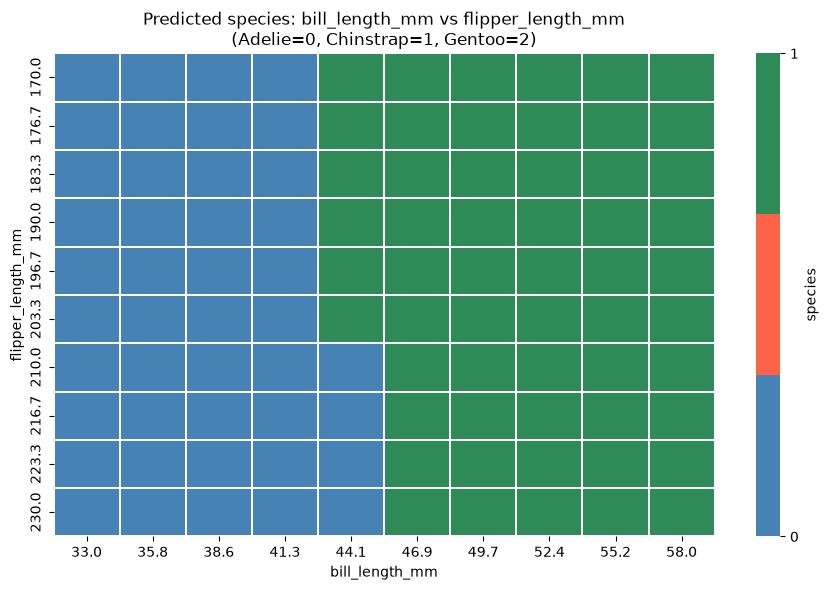

2026-08-13 15:57:25 | INFO | M07 | ANALYST CHOICE: What does the boundary shape tell you about the model?


In [4]:
# === Section 4. Prediction Grid ===

# CUSTOM: adjust ranges based on your investigation in Section 3.
bill_length_values = list(np.linspace(33, 58, 10))
flipper_length_values = list(np.linspace(170, 230, 10))

rows = []
for bl in bill_length_values:
    for fl in flipper_length_values:
        payload = {**BASE, "bill_length_mm": bl, "flipper_length_mm": fl}
        rows.append(
            {
                "bill_length_mm": round(bl, 1),
                "flipper_length_mm": round(fl, 1),
                "prediction": predict(payload),
            }
        )

df_grid = pd.DataFrame(rows)
species_to_int = {"Adelie": 0, "Chinstrap": 1, "Gentoo": 2}
df_grid["species_int"] = df_grid["prediction"].map(species_to_int).fillna(-1)

pivot = df_grid.pivot(
    index="flipper_length_mm",
    columns="bill_length_mm",
    values="species_int",
)

plt.figure(figsize=(9, 6))
sns.heatmap(
    pivot,
    cmap=["steelblue", "tomato", "seagreen"],
    linewidths=0.3,
    cbar_kws={"ticks": [0, 1, 2], "label": "species"},
)
plt.title(
    "Predicted species: bill_length_mm vs flipper_length_mm\n(Adelie=0, Chinstrap=1, Gentoo=2)"
)
plt.tight_layout()
plt.show()

LOG.info("ANALYST CHOICE: What does the boundary shape tell you about the model?")

## Section 5. Edge Cases

```text
ANALYST CHOICE
What happens with unusual or invalid inputs?
A robust API should handle bad input gracefully.
Decide if this one does.
```

In [5]:
# === Section 5. Edge Cases ===

edge_cases: list[tuple[str, dict[str, Any]]] = [
    (
        "missing feature",
        {"bill_length_mm": 39.1, "bill_depth_mm": 18.7, "flipper_length_mm": 181},
    ),
    (
        "extreme bill length",
        {
            "bill_length_mm": 1.0,
            "bill_depth_mm": 18.7,
            "flipper_length_mm": 181,
            "body_mass_g": 3750,
        },
    ),
    (
        "very large bill",
        {
            "bill_length_mm": 999.0,
            "bill_depth_mm": 18.7,
            "flipper_length_mm": 181,
            "body_mass_g": 3750,
        },
    ),
    (
        "negative value",
        {
            "bill_length_mm": -10.0,
            "bill_depth_mm": 18.7,
            "flipper_length_mm": 181,
            "body_mass_g": 3750,
        },
    ),
    (
        "zero body mass",
        {
            "bill_length_mm": 39.1,
            "bill_depth_mm": 18.7,
            "flipper_length_mm": 181,
            "body_mass_g": 0,
        },
    ),
]

LOG.info("Edge case results:")
for label, payload in edge_cases:
    result = predict(payload)
    LOG.info(f"  {label:<22} -> {result}")

LOG.info("ANALYST CHOICE: Which edge cases were handled cleanly and which were not?")

2026-08-13 15:57:25 | INFO | M07 | Edge case results:
2026-08-13 15:57:25 | INFO | M07 |   missing feature        -> ERROR: 400 Client Error: Bad Request for url: https://ml-penguin-predictor.onrender.com/predict
2026-08-13 15:57:25 | INFO | M07 |   extreme bill length    -> Adelie
2026-08-13 15:57:25 | INFO | M07 |   very large bill        -> Chinstrap
2026-08-13 15:57:25 | INFO | M07 |   negative value         -> Adelie
2026-08-13 15:57:25 | INFO | M07 |   zero body mass         -> Adelie
2026-08-13 15:57:25 | INFO | M07 | ANALYST CHOICE: Which edge cases were handled cleanly and which were not?


## Section 6. Summary and Next Steps

First, output key information (may use Python)
Second, provide your narrative, conclusions, and next steps (in Markdown)

In [6]:
# === Section 6. Summary ===


def summarize() -> None:
    """Record what was investigated and the judgment still owed."""
    LOG.info("========================")
    LOG.info("SUMMARY")
    LOG.info("========================")
    LOG.info(f"API endpoint: {API_URL}")
    LOG.info("========================")


summarize()

2026-08-13 15:57:25 | INFO | M07 | ========================
2026-08-13 15:57:25 | INFO | M07 | SUMMARY
2026-08-13 15:57:25 | INFO | M07 | ========================
2026-08-13 15:57:25 | INFO | M07 | API endpoint: https://ml-penguin-predictor.onrender.com/predict
2026-08-13 15:57:25 | INFO | M07 | ========================


### Narrative

For this project, I investigated the deployed penguins classification model by 
confirming baseline predictions, testing feature sensitivity, creating a prediction 
grid, and testing edge cases. The `bill_length_mm` sweep had the clearest influence 
on the prediction compared to `body_mass_g` and `flipper_length_mm`. For the 
`bill_length_mm` sweep, the prediction first shifts away from Adelie to Chinstrap 
at approximately 42.76 mm and remains Chinstrap through that range. The 
`body_mass_g` and `flipper_length_mm` sweeps continued to predict Adelie across the
tested ranges when the other features were held constant. This finding suggests that 
bill length has a stronger influence for this baseline. 

The edge case showed that the API could still return predictions for some unrealistic
values. One thing I would do to improve the API contract would be to add validation to 
reject unrealistic penguin measurements.  

### Conclusions

This is SUPERVISED learning (because the model was trained with a known target).

The target is `species`, a category column, so the model performs classification.

We investigated the model's behavior from the outside by varying inputs and observing predictions.

### Next Steps

My next steps would be to add stronger API validation for impossible values such as negative
measurements or zero body mass. 
